# RETO 3: CLASIFICACION DE FLORES

### Importar librerías

In [10]:
from urllib.request import urlretrieve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, ConfusionMatrixDisplay, classification_report

### Traer y leer Dataset

In [11]:
irisURL = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(irisURL)
df_iris = pd.read_csv(irisURL, sep=',', names=["Largo_Sepalo", "Ancho_Sepalo", "Largo_Petalo", "Ancho_Petalo", "Clase"])
df_iris = df_iris.dropna()
le = LabelEncoder()
df_iris["Clase"] = le.fit_transform(df_iris["Clase"])

In [12]:
print(df_iris)
print(df_iris.head())
print(df_iris.tail())

     Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo  Clase
0             5.1           3.5           1.4           0.2      0
1             4.9           3.0           1.4           0.2      0
2             4.7           3.2           1.3           0.2      0
3             4.6           3.1           1.5           0.2      0
4             5.0           3.6           1.4           0.2      0
..            ...           ...           ...           ...    ...
145           6.7           3.0           5.2           2.3      2
146           6.3           2.5           5.0           1.9      2
147           6.5           3.0           5.2           2.0      2
148           6.2           3.4           5.4           2.3      2
149           5.9           3.0           5.1           1.8      2

[150 rows x 5 columns]
   Largo_Sepalo  Ancho_Sepalo  Largo_Petalo  Ancho_Petalo  Clase
0           5.1           3.5           1.4           0.2      0
1           4.9           3.0           1.

## <span style="color:yellow">K-Means</span>

### Separar X (no usamos Y para entrenar)

In [13]:
X_kmeans = df_iris.drop("Clase", axis=1).copy()
y_real = df_iris["Clase"].copy()  # solo para evaluar

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans)

### Método del codo

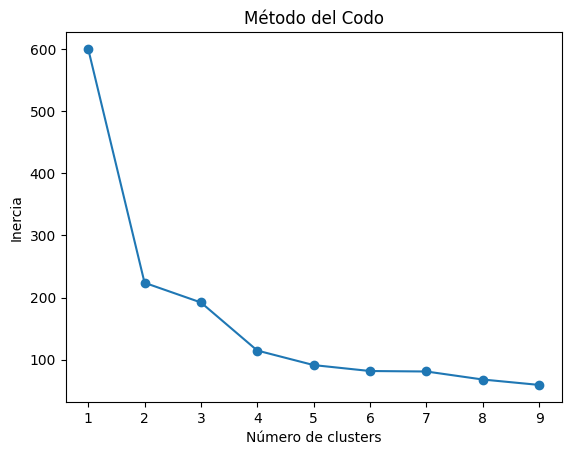

In [14]:
inercia = []

for k in range(1, 10):
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(X_kmeans_scaled)
    inercia.append(modelo.inertia_)

plt.plot(range(1,10), inercia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

### Entrenar modelo logístico, predicciones

In [15]:
modelo_kmeans = KMeans(n_clusters=3, random_state=42)
modelo_kmeans.fit(X_kmeans_scaled)

pred_kmeans = modelo_kmeans.labels_

### Validaciones

Accuracy KMeans: 0.0


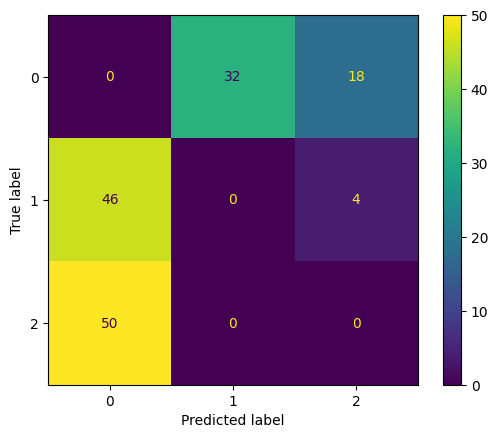

In [17]:

y_real = df_iris["Clase"]
accuracy_kmeans = accuracy_score(y_real, pred_kmeans)
print("Accuracy KMeans:", accuracy_kmeans)

ConfusionMatrixDisplay.from_predictions(y_real, pred_kmeans)
plt.show()

### Cambiar Hiperparametros

Mejores parámetros: {'init': 'random', 'max_iter': 300, 'n_clusters': 4, 'n_init': 10} con precisión realista de: 0.47333333333333333
Precision en dataset completo:  0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      50.0
           1       0.00      0.00      0.00      50.0
           2       0.00      0.00      0.00      50.0
           3       0.00      0.00      0.00       0.0

    accuracy                           0.00     150.0
   macro avg       0.00      0.00      0.00     150.0
weighted avg       0.00      0.00      0.00     150.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


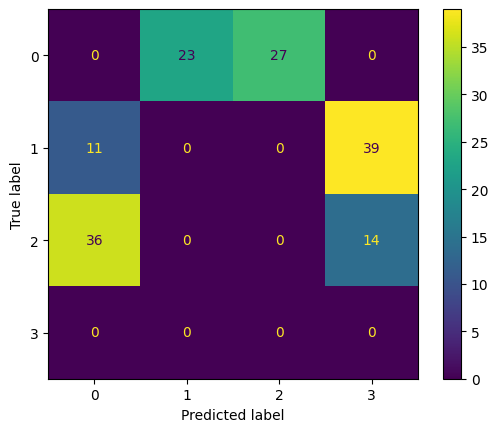

In [ ]:
param_grid = {
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'max_iter': [300, 500, 700]
}

grid_kmeans = GridSearchCV(
    KMeans(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_kmeans.fit(X_kmeans_scaled, y_real)

print(f"Mejores parámetros: {grid_kmeans.best_params_} con precisión realista de: {grid_kmeans.best_score_}")

## <span style="color:yellow">Perceptron Multicapa</span>

### Separar X, y, entrenamiento y pruebas

In [20]:
X_mlp = df_iris.drop("Clase", axis=1).copy()
y_mlp = df_iris["Clase"].copy()

scaler = StandardScaler()
X_mlp_scaled = scaler.fit_transform(X_mlp)

X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(
    X_mlp_scaled, y_mlp, test_size=0.3, random_state=42
)

### Entrenar modelo y predicciones

In [21]:
modelo_mlp = MLPClassifier(random_state=42, max_iter=1000)

modelo_mlp.fit(X_train_mlp, y_train_mlp)

pred_mlp = modelo_mlp.predict(X_test_mlp)

### Validaciones

Accuracy MLP: 1.0


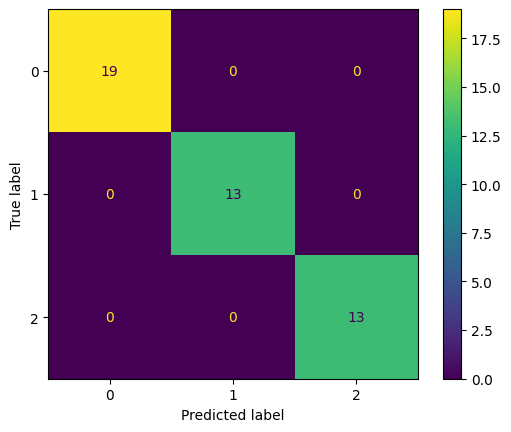

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [22]:
accuracy_mlp = accuracy_score(y_test_mlp, pred_mlp)
print("Accuracy MLP:", accuracy_mlp)

ConfusionMatrixDisplay.from_predictions(y_test_mlp, pred_mlp)
plt.show()

print(classification_report(y_test_mlp, pred_mlp))

### Cambiar Hiperparametros

Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 30), 'learning_rate': 'constant'} con precisión realista de: 0.9523809523809523
Precision en test:  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



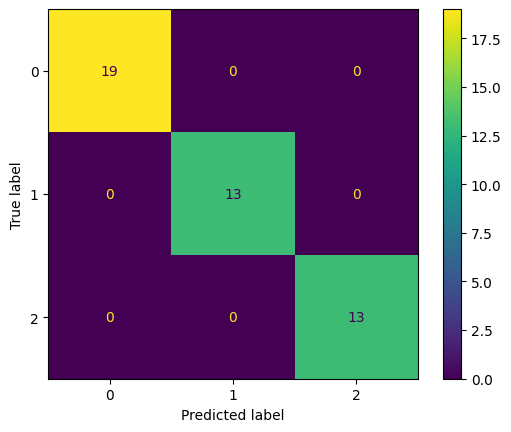

In [26]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,30), (100,50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=42),
    param_grid_mlp,
    cv=5,
    scoring='accuracy'
)

grid_mlp.fit(X_train_mlp, y_train_mlp)

print(f"Mejores parámetros: {grid_mlp.best_params_} con precisión realista de: {grid_mlp.best_score_}")

pred_mlp_grid = grid_mlp.predict(X_test_mlp)
best_mlp = grid_mlp.best_estimator_
pred_best_mlp = best_mlp.predict(X_test_mlp)

print("Precision en test: ", accuracy_score(y_test_mlp, pred_mlp_grid))
print(classification_report(y_test_mlp, pred_mlp_grid))

ConfusionMatrixDisplay.from_predictions(y_test_mlp, pred_mlp_grid)
plt.show()

In [ ]:


print("Accuracy optimizado:", accuracy_score(y_test_mlp, pred_best_mlp))

Accuracy optimizado: 1.0


In [ ]:
nueva_flor = np.array([[8, 3, 8, 0.2]])

prediccion_kmeans = grid_kmeans.predict(nueva_flor)
prediccion_perceptron = best_mlp.predict(nueva_flor)

print(f"Predicción de Bayes Ingenuos para la nueva flor: {prediccion_kmeans[0]}")
print(f"Predicción de SVM para la nueva flor: {prediccion_perceptron[0]}")